In [29]:
#import zipfile
import os

file_path_A = os.getcwd() + "\\Exp-A_HDF5_Run-1.zip"
file_path_B = os.getcwd() + "\\Exp-B_HDF5_Run-1.zip"
file_path_C = os.getcwd() + "\\Exp-C_HDF5_Run-1.zip"


#with zipfile.ZipFile(file_path, "r") as zip_ref:
    #print(zip_ref.namelist())

In [19]:
import h5py
'''
f = h5py.File( "sample_extract/Run-1/Dyno Gear233Run1_00000.hdf5",
    "r"
)

print(list(f.keys()))

def print_structure(name, obj):
    print(name)

f.visititems(print_structure)
'''

'\nf = h5py.File( "sample_extract/Run-1/Dyno Gear233Run1_00000.hdf5",\n    "r"\n)\n\nprint(list(f.keys()))\n\ndef print_structure(name, obj):\n    print(name)\n\nf.visititems(print_structure)\n'

# sample size of dataset

In [31]:
import zipfile
import h5py
import numpy as np
import io

def extract_features_from_zip(zip_path, hdf5_filename, downsample=10):
    with zipfile.ZipFile(zip_path, 'r') as z:
        with z.open(hdf5_filename) as f:
            file_bytes = f.read()
            file_obj = io.BytesIO(file_bytes)

            with h5py.File(file_obj, 'r') as hdf:

                rms = hdf["CI/rms"][:]
                kurtosis = hdf["CI/kurtosis"][:]
                speed = hdf["Context/PAU Speed"][:]
                torque = hdf["Context/PAU Torque"][:]

                # Downsampling
                rms = rms[::downsample]
                kurtosis = kurtosis[::downsample]
                speed = speed[::downsample]
                torque = torque[::downsample]

                features = np.stack([rms, kurtosis, speed, torque], axis=1)
    return features

def find_file_in_zip(zip_path, target_name):
    with zipfile.ZipFile(zip_path, 'r') as z:
        for name in z.namelist():
            if target_name in name:
                return name
    return None






In [33]:
#keep gears isolated
path_to_gear = {
    file_path_A: "gear1",
    file_path_B: "gear2",
    file_path_C: "gear3",
}
path_to_gear = {
    file_path_A: "gear1",
    file_path_B: "gear2",
    file_path_C: "gear3",
}

gear_to_prefix = {
    "gear1": "Dyno Gear233Run1_",
    "gear2": "Dyno Gear303Run1_",
    "gear3": "Dyno Gear303Run1_",
}

paths = [file_path_A, file_path_B, file_path_C]
data = {"gear1": [], "gear2": [], "gear3": []}

for path in paths:
    gear_key = path_to_gear[path]
    prefix = gear_to_prefix[gear_key]

    all_features = []
    for i in range(0, 21):
        filename = f"{prefix}{i:05d}.hdf5"
        real_path = find_file_in_zip(path, filename)
        features = extract_features_from_zip(path, real_path)
        all_features.append(features)

    sample_dataset = np.concatenate(all_features, axis=0)
    print(gear_key, sample_dataset.shape)

    data[gear_key].append(sample_dataset)


gear1 (123, 4)
gear2 (123, 4)


ValueError: all input arrays must have the same shape

## sliding windows

In [9]:
import numpy as np

def make_windows(data, window_size=20, stride=1):
    X = []
    for i in range(0, len(data) - window_size, stride):
        X.append(data[i:i+window_size])
    return np.array(X)  # (n_samples, window_size, n_features)

def flatten_windows(X):
    return X.reshape(X.shape[0], -1)  # (n_samples, window_size*n_features)

def stats_features(X):
    # X: (n_samples, window_size, n_features)
    mean = X.mean(axis=1)
    std  = X.std(axis=1)
    mx   = X.max(axis=1)
    mn   = X.min(axis=1)
    return np.concatenate([mean, std, mx, mn], axis=1)  # (n_samples, 4*n_features)


def window_features_stats(Xw):
    # Xw: (n_samples, window, n_features)
    mean = Xw.mean(axis=1)
    std  = Xw.std(axis=1)
    mn   = Xw.min(axis=1)
    mx   = Xw.max(axis=1)

    # Trend (lineare Steigung) je Feature
    t = np.arange(Xw.shape[1])
    t = (t - t.mean()) / (t.std() + 1e-9)
    slope = (Xw * t[None, :, None]).mean(axis=1)  # proportional zur Steigung

    return np.concatenate([mean, std, mn, mx, slope], axis=1)


In [ ]:
#dataset from multiple gears/runs, keep order
import numpy as np

def build_window_dataset(data_dict, gears, window_size, stride, label_mode, feature_mode):
    X_all, y_all = [], []
    meta = []  # (gear_id, run_id, window_index)

    for gear_id in gears:
        runs = data_dict[gear_id]
        for run_id, seq in enumerate(runs):
            # 1) windows within THIS run only
            Xw = make_windows(seq, window_size=window_size, stride=stride)

            # 2) proxy labels within THIS run (or within gear)
            y = create_proxy_labels(len(Xw), mode=label_mode)

            # 3) features
            if feature_mode == "flat":
                X = flatten_windows(Xw)
            elif feature_mode == "stats":
                X = window_features_stats(Xw)
            else:
                raise ValueError("feature_mode must be 'flat' or 'stats'")

            X_all.append(X)
            y_all.append(y)
            meta += [(gear_id, run_id, i) for i in range(len(y))]

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)
    meta = np.array(meta, dtype=object)
    return X_all, y_all, meta

In [ ]:
#gear isloated split
#train on two gears, tes on one

train_gears = ["gear1", "gear2"]
test_gears  = ["gear3"]

X_train, y_train, meta_train = build_window_dataset(data, train_gears, window_size, stride, label_mode, feature_mode)
X_test,  y_test,  meta_test  = build_window_dataset(data, test_gears,  window_size, stride, label_mode, feature_mode)

#test gear is fully isolated: no shared samples, no shared windows, no shared scaling

## proxy labels

In the absence of explicit failure labels, proxy labels are constructed based on the temporal ordering of samples within a run-to-failure experiment.
These labels are constructed based on the first and last run of the gears. This provides end-of-life (failure) signal, helps define a real damage scale and
covers nonlinear region

In [ ]:
#That makes labels comparable across runs
def create_proxy_labels_run_segment(n, run_id, n_runs, mode="linear"):
    base = np.linspace(0, 1, n) if mode=="linear" else np.arange(n)
    start = run_id / n_runs
    end   = (run_id + 1) / n_runs
    return start + base * (end - start)

In [10]:
#X[0] → almost healthy → y ≈ 0.0 
#X[-1] → almost failure → y ≈ 1.0  
#f(X) → "Position in lifecycle" not actual physical degradation
import numpy as np

def create_proxy_labels(num_samples, mode="linear"):
    t = np.arange(num_samples)
    T = num_samples - 1  # wichtig: Normierung 0→1

    if mode == "linear":
        y = t / T

    elif mode == "quadratic":
        y = (t / T) ** 2

    elif mode == "log":
        y = np.log(1 + t) / np.log(1 + T)

    else:
        raise ValueError("Unknown mode")

    return y


In [9]:
X = create_windows(sample_dataset, window_size=20)

y_linear = create_proxy_labels(len(X), mode="linear")
y_quadratic = create_proxy_labels(len(X), mode="quadratic")
y_log = create_proxy_labels(len(X), mode="log")

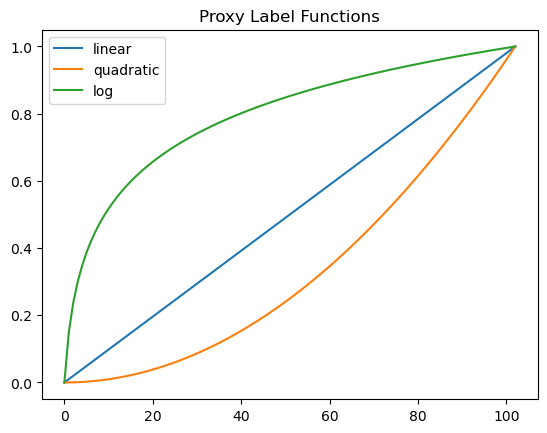

In [10]:
import matplotlib.pyplot as plt

plt.plot(y_linear, label="linear")
plt.plot(y_quadratic, label="quadratic")
plt.plot(y_log, label="log")

plt.legend()
plt.title("Proxy Label Functions")
plt.show()

## Model Training and Testing
Random forest regression

In [ ]:
def time_split(X, y, test_size=0.2): #with stride=1 and window_size=20, consecutive windows share 19/20 samples
    n = len(y)
    cut = int(n * (1 - test_size))
    return X[:cut], X[cut:], y[:cut], y[cut:]

#leakage caused by overlapping windows
#trying to prevent too similar test and training set
def time_split_with_gap(X, y, test_size=0.2, gap=20): 
    n = len(X)
    n_test = int(n * test_size)
    split = n - n_test

    # [split-gap, split+gap)
    train_end = max(0, split - gap)
    test_start = min(n, split + gap)

    X_train, y_train = X[:train_end], y[:train_end]
    X_test,  y_test  = X[test_start:], y[test_start:]

    return X_train, X_test, y_train, y_test

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

def make_model(name="rf", **kwargs):
    if name == "rf":
        return RandomForestRegressor(
            n_estimators=300, random_state=42, n_jobs=-1, **kwargs
        )
    if name == "ridge":
        return Ridge(**kwargs)
    if name == "svr":
        return SVR(**kwargs)
    raise ValueError(f"Unknown model: {name}")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def run_experiment(sample_dataset,
                   window_size=20,
                   stride=1,
                   label_mode="linear",
                   feature_mode="flat",   # "flat" oder "stats"
                   model_name="rf",
                   test_size=0.2,
                   model_params=None):

    # 1) windows
    Xw = make_windows(sample_dataset, window_size=window_size, stride=stride)

    # 2) labels
    y = create_proxy_labels(len(Xw), mode=label_mode)

    # 3) features
    if feature_mode == "flat":
        X = flatten_windows(Xw)
    elif feature_mode == "stats":
        X = window_features_stats(Xw)
    else:
        raise ValueError("feature_mode must be 'flat' or 'stats'")

    # 4) split
    X_train, X_test, y_train, y_test = time_split_with_gap(X, y, test_size=test_size)

    # 5) model
    model_params = model_params or {}
    model = make_model(model_name, **model_params)
    model.fit(X_train, y_train)

    # 6) eval
    y_pred = model.predict(X_test)
    metrics = {
        "mse": mean_squared_error(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred),
        "r2":  r2_score(y_test, y_pred),
        "n_train": len(y_train),
        "n_test": len(y_test),
    }

    y_base = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
    print("Baseline MSE:", mean_squared_error(y_test, y_base))
    print("Model MSE:", mean_squared_error(y_test, y_pred))

    return model, metrics, (y_test, y_pred)

In [ ]:
'''
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

def train_different_labels(function="linear"):
    y = create_proxy_labels(len(X), function)
    X_flat = X.reshape(X.shape[0], -1)
    print(X_flat.shape)
    X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, shuffle=False #no shuffle to keep time order
)
    return X_train, X_test, y_train, y_test
    
'''

In [16]:
configs = [
    ("linear", "rf",   "flat"),
    ("quadratic", "rf","flat"),
    ("log", "rf",      "flat"),
    ("linear", "ridge","stats"),
    ("linear", "svr",  "stats"),
]

results = []
for label_mode, model_name, feat_mode in configs:
    _, m, _ = run_experiment(
        sample_dataset,
        window_size=20,
        label_mode=label_mode,
        feature_mode=feat_mode,
        model_name=model_name
    )
    results.append((label_mode, model_name, feat_mode, m))

results

Baseline MSE: 0.2584502755350506
Model MSE: 0.04000163230869703
Baseline MSE: 0.37817201326193656
Model MSE: 0.09965307023694857
Baseline MSE: 0.05506936981992142
Model MSE: 0.0030151300190924737
Baseline MSE: 0.2584502755350506
Model MSE: 0.06548313487840107
Baseline MSE: 0.2584502755350506
Model MSE: 0.16663457756882796


[('linear',
  'rf',
  'flat',
  {'mse': 0.04000163230869703,
   'mae': 0.18850451291627796,
   'r2': -10.35028134199138,
   'n_train': 82,
   'n_test': 21}),
 ('quadratic',
  'rf',
  'flat',
  {'mse': 0.09965307023694857,
   'mae': 0.2969685804605071,
   'r2': -7.681819278257791,
   'n_train': 82,
   'n_test': 21}),
 ('log',
  'rf',
  'flat',
  {'mse': 0.0030151300190924737,
   'mae': 0.052720498058848604,
   'r2': -14.18689892297396,
   'n_train': 82,
   'n_test': 21}),
 ('linear',
  'ridge',
  'stats',
  {'mse': 0.06548313487840107,
   'mae': 0.25071470964289233,
   'r2': -17.580541871133224,
   'n_train': 82,
   'n_test': 21}),
 ('linear',
  'svr',
  'stats',
  {'mse': 0.16663457756882796,
   'mae': 0.4038781872733927,
   'r2': -46.281803955256905,
   'n_train': 82,
   'n_test': 21})]

In [23]:
print(type(results))
print(len(results))
print(results)

<class 'list'>
5
[('linear', 'rf', 'flat', {'mse': 0.04000163230869703, 'mae': 0.18850451291627796, 'r2': -10.35028134199138, 'n_train': 82, 'n_test': 21}), ('quadratic', 'rf', 'flat', {'mse': 0.09965307023694857, 'mae': 0.2969685804605071, 'r2': -7.681819278257791, 'n_train': 82, 'n_test': 21}), ('log', 'rf', 'flat', {'mse': 0.0030151300190924737, 'mae': 0.052720498058848604, 'r2': -14.18689892297396, 'n_train': 82, 'n_test': 21}), ('linear', 'ridge', 'stats', {'mse': 0.06548313487840107, 'mae': 0.25071470964289233, 'r2': -17.580541871133224, 'n_train': 82, 'n_test': 21}), ('linear', 'svr', 'stats', {'mse': 0.16663457756882796, 'mae': 0.4038781872733927, 'r2': -46.281803955256905, 'n_train': 82, 'n_test': 21})]


In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_true_vs_pred(y_test, y_pred, title="True vs Pred"):
    plt.figure(figsize=(10,4))
    plt.plot(y_test, marker="o", label="True")
    plt.plot(y_pred, marker="o", label="Pred")
    plt.title(title)
    plt.xlabel("Test index (time order)")
    plt.ylabel("Proxy label")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [34]:
'''results.append((transform, algo, feats, metrics, (y_test, y_pred)))
best = min(results, key=lambda r: r[3]["mse"])   # r[3] ist metrics
transform, algo, feats, metrics, (y_test, y_pred) = best
plot_true_vs_pred(y_test, y_pred)'''

'results.append((transform, algo, feats, metrics, (y_test, y_pred)))\nbest = min(results, key=lambda r: r[3]["mse"])   # r[3] ist metrics\ntransform, algo, feats, metrics, (y_test, y_pred) = best\nplot_true_vs_pred(y_test, y_pred)'

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error



y_base = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
print("Baseline MSE:", mean_squared_error(y_test, y_base))
print("Model MSE:", mean_squared_error(y_test, y_pred))